# Students Performance Indicator

### 1) Problem statement
- This project understands how the student's performance (test scores) is affected by various factors such as Gender, Ethnicity, Parental level of education, Lunch and Test preparation course.


### 2) Data Collection
- Dataset Source - https://www.kaggle.com/datasets/spscientist/students-performance-in-exams?datasetId=74977
- The data consists of 8 column and 1000 rows.

### 2.1) Importing Data and Required Packages

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("./data/StudentsPerformance.csv")
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [3]:
df.shape

(1000, 8)

### 3. Data Checks to perform

- Check Missing values
- Check Duplicates
- Check data type
- Check the number of unique values of each column
- Check statistics of data set
- Check various categories present in the different categorical column

#### 2.2) Dataset Information Analysis

- gender: male/female
- race_ethnicity: group (A, B, C, D, E)
- Parents Education level: bachelor's degree, masters degree, associate's degree, high school
- lunch: Have eaten or not (standard, free/reduced)
- test preparation courses: none, completed

### 3. Data Checks to perform

- Check Missing values
- Check Duplicates
- Check data type
- Check the number of unique values of each column
- Check statistics of data set
- Check various categories present in the different categorical column

#### 3.1) check for missing values 

In [4]:
df.isna().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

##### There is no missing values in the dataset

#### 3.2) Check Duplicate

In [5]:
df.duplicated().sum()

np.int64(0)

##### There is no duplicated data

#### 3.3) Check data types

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


#### Checking for Unique values in each column

In [7]:
df.nunique()

gender                          2
race/ethnicity                  5
parental level of education     6
lunch                           2
test preparation course         2
math score                     81
reading score                  72
writing score                  77
dtype: int64

#### 3.4) Check Statistical information

In [8]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


##### Insights
- All __means__ are between 66 and 68.05
- All __standard deviation__ are between 14.61 and 15.196

#### 3.7) Exploring Data

In [9]:
# print(f"Categories in gender feature:   {df.gender.unique().tolist()}")
print(f"Categories in gender feature:   {', '.join(df.gender.unique())}")
print(f"Distinct values in race/ethnicity feature:   {', '.join(df['race/ethnicity'].unique())}")
print(f"Distinct values in parents education level:   {', '.join(df['parental level of education'].unique())}")
print(f"Distinct values in lunch feature:   {', '.join(df.lunch.unique())}")
print(f"Distinct values in test preparation scorers:    {', '.join(df['test preparation course'].unique())}")

Categories in gender feature:   female, male
Distinct values in race/ethnicity feature:   group B, group C, group A, group D, group E
Distinct values in parents education level:   bachelor's degree, some college, master's degree, associate's degree, high school, some high school
Distinct values in lunch feature:   standard, free/reduced
Distinct values in test preparation scorers:    none, completed


In [10]:
# Defining numerical and categorical features
numerical_features=df.select_dtypes(include=np.number).columns.tolist()
categorical_features=df.select_dtypes(include="string").columns.tolist()

print(f"There are {len(numerical_features)} numerical features Features and they are:  {numerical_features}")
print(f"There are {len(categorical_features)} categorical features Features and they are:  {categorical_features}")

There are 3 numerical features Features and they are:  ['math score', 'reading score', 'writing score']
There are 5 categorical features Features and they are:  ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']


#### 3.8) Creating new columns :
        [Total Score, Average]

In [11]:
df['Total_score']= df['math score']+ df['reading score']+ df['writing score']
df['Average_score']=df['Total_score']/3

In [12]:
df.head(3)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,Total_score,Average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667


In [13]:
full_marks_maths= (df['math score']==100).sum()
full_marks_reading= (df['reading score']==100).sum()
full_marks_writing= (df['writing score']==100).sum()

print(f"Students with full marks in Maths: {full_marks_maths}")
print(f"Students with full marks in reading: {full_marks_reading}")
print(f"Students with full marks in writing: {full_marks_writing}")


Students with full marks in Maths: 7
Students with full marks in reading: 17
Students with full marks in writing: 14


In [14]:
less_than_40_maths= (df['math score']<40).sum()
less_than_40_reading= (df['reading score']<40).sum()
less_than_40_writing= (df['writing score']<40).sum()

print(f"Students scoring less than 40 in Maths: {less_than_40_maths}")
print(f"Students scoring less than 40 in Reading: {less_than_40_reading}")
print(f"Students scoring less than 40 in Writing: {less_than_40_writing}")


Students scoring less than 40 in Maths: 40
Students scoring less than 40 in Reading: 26
Students scoring less than 40 in Writing: 32


In [15]:
less_than_20_maths= (df['math score']<20).sum()
less_than_20_reading= (df['reading score']<20).sum()
less_than_20_writing= (df['writing score']<20).sum()

print(f"Students scoring less than 20 in Maths: {less_than_20_maths}")
print(f"Students scoring less than 20 in Reading: {less_than_20_reading}")
print(f"Students scoring less than 20 in Writing: {less_than_20_writing}")


Students scoring less than 20 in Maths: 4
Students scoring less than 20 in Reading: 1
Students scoring less than 20 in Writing: 3


In [16]:
print('Maths== ',df['math score'].min())
print('Reading==',df['reading score'].min())
print("Writhing==",df['writing score'].min())

Maths==  0
Reading== 17
Writhing== 10


#### Insight
- Students have performed worst in the subject of maths
- Reading has the highest performance

### 4) EDA (__Visualization__)

Visualize the average score distribution 

##### Average score and average score with gender

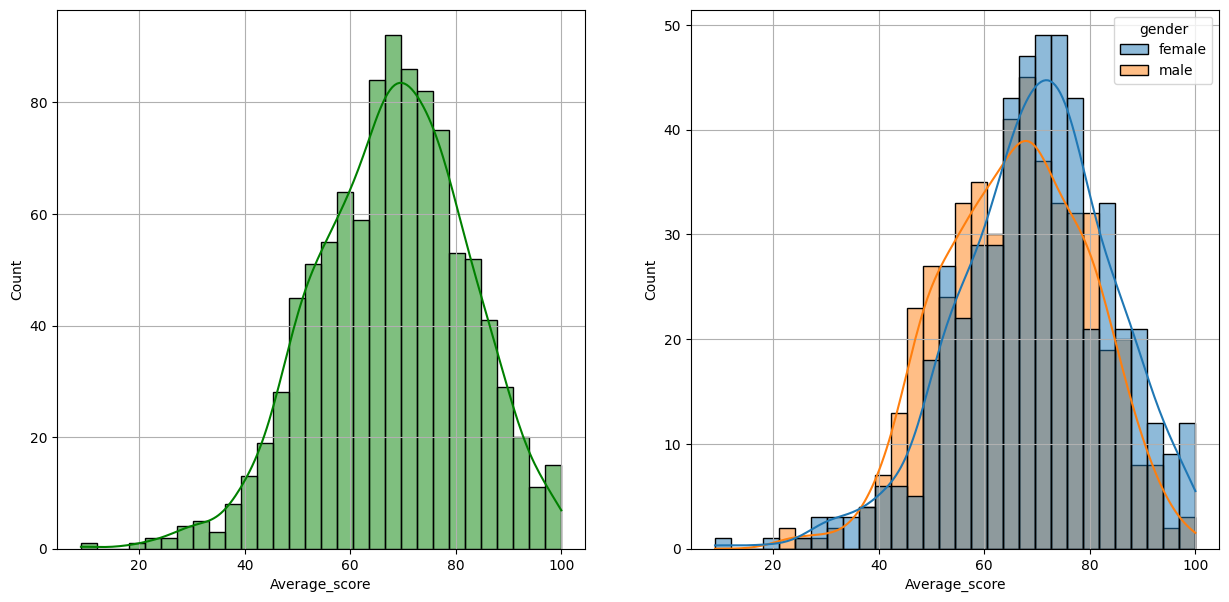

In [17]:
fig, ax= plt.subplots(1,2, figsize=(15,7))
plt.subplot(121)
sns.histplot(data=df, x='Average_score', kde=True,bins=30, color='g')
plt.grid()
plt.subplot(122)
sns.histplot(data=df, x='Average_score', kde=True, bins=30, hue='gender')
plt.grid()
plt.show()

##### Insights
- Female students has a better performance record than male students

##### Effect of lunch on test score

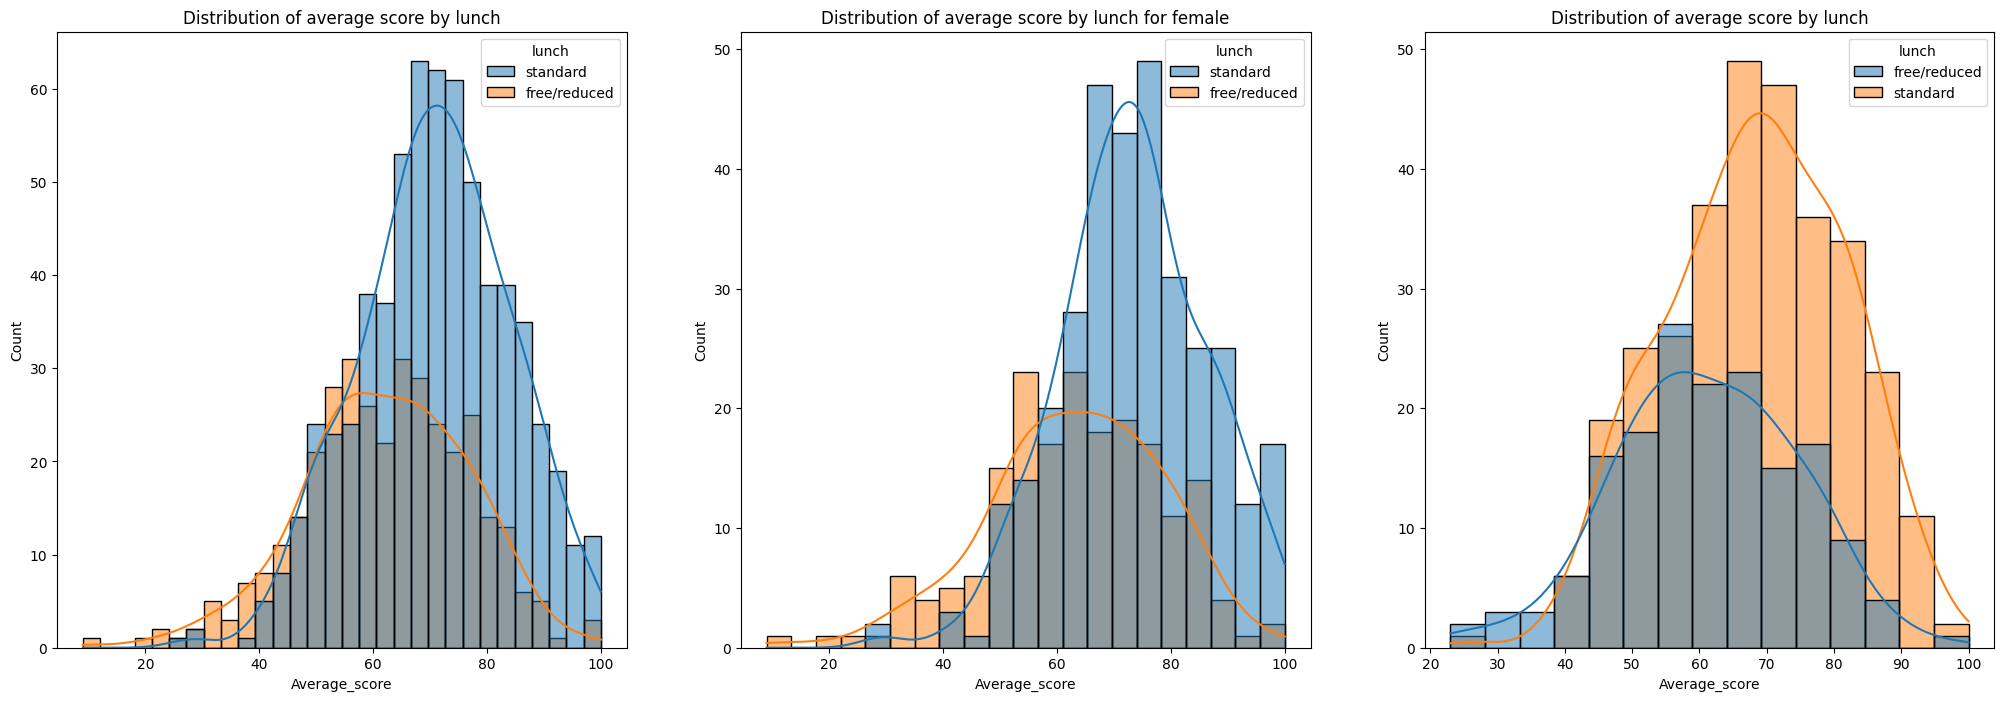

In [18]:
plt.subplots(1,3, figsize=(25,8))

plt.subplot(131)
plt.title("Distribution of average score by lunch")
sns.histplot(data=df, x='Average_score', kde= True, bins=30, hue='lunch')

plt.subplot(132)
plt.title("Distribution of average score by lunch for female")
sns.histplot(df[df.gender=='female'], x='Average_score', kde='True', hue='lunch')

plt.subplot(133)
plt.title("Distribution of average score by lunch")
sns.histplot(data=df[df.gender=='male'], x='Average_score', kde=True, hue='lunch',)

plt.show()

In [19]:
contingency_table=pd.crosstab(df.gender, df.lunch)
contingency_table

lunch,free/reduced,standard
gender,,
female,189,329
male,166,316


In [20]:
from scipy.stats import chi2_contingency

# Run the test
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-Square Statistic: {chi2}")
print(f"P-value: {p_value}")

# Interpret the result
alpha = 0.05
if p_value < alpha:
    print("There is a statistically significant difference between gender and lunch type.")
else:
    print("No significant difference found (the groups are independent).")


Chi-Square Statistic: 0.37173802316040705
P-value: 0.5420584175146086
No significant difference found (the groups are independent).


<Axes: xlabel='gender', ylabel='count'>

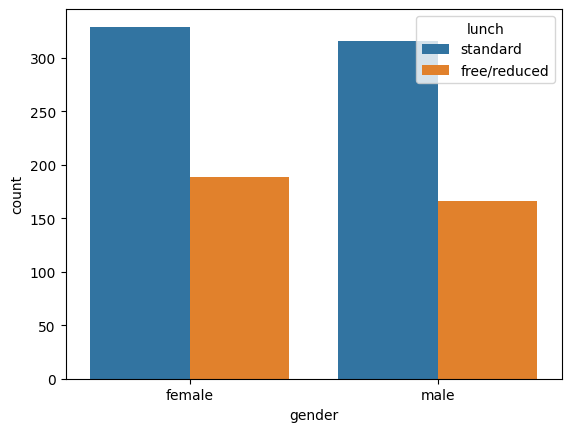

In [21]:
sns.countplot(data=df, x='gender', hue='lunch')

#### Insights
- Students provided with standard lunches perform significantly better irrespectively of their gender
- Female students perform significantly better when compared to males when provided with lunch.
- There is no significant difference between the groups [in account to the lunch provide]

##### Parents level of education on test score

In [22]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score', 'Total_score', 'Average_score'],
      dtype='str')

#### Effect of parental education on test scores

<Axes: title={'center': 'Male Students Average test score by parental level of education'}, xlabel='Average_score', ylabel='Count'>

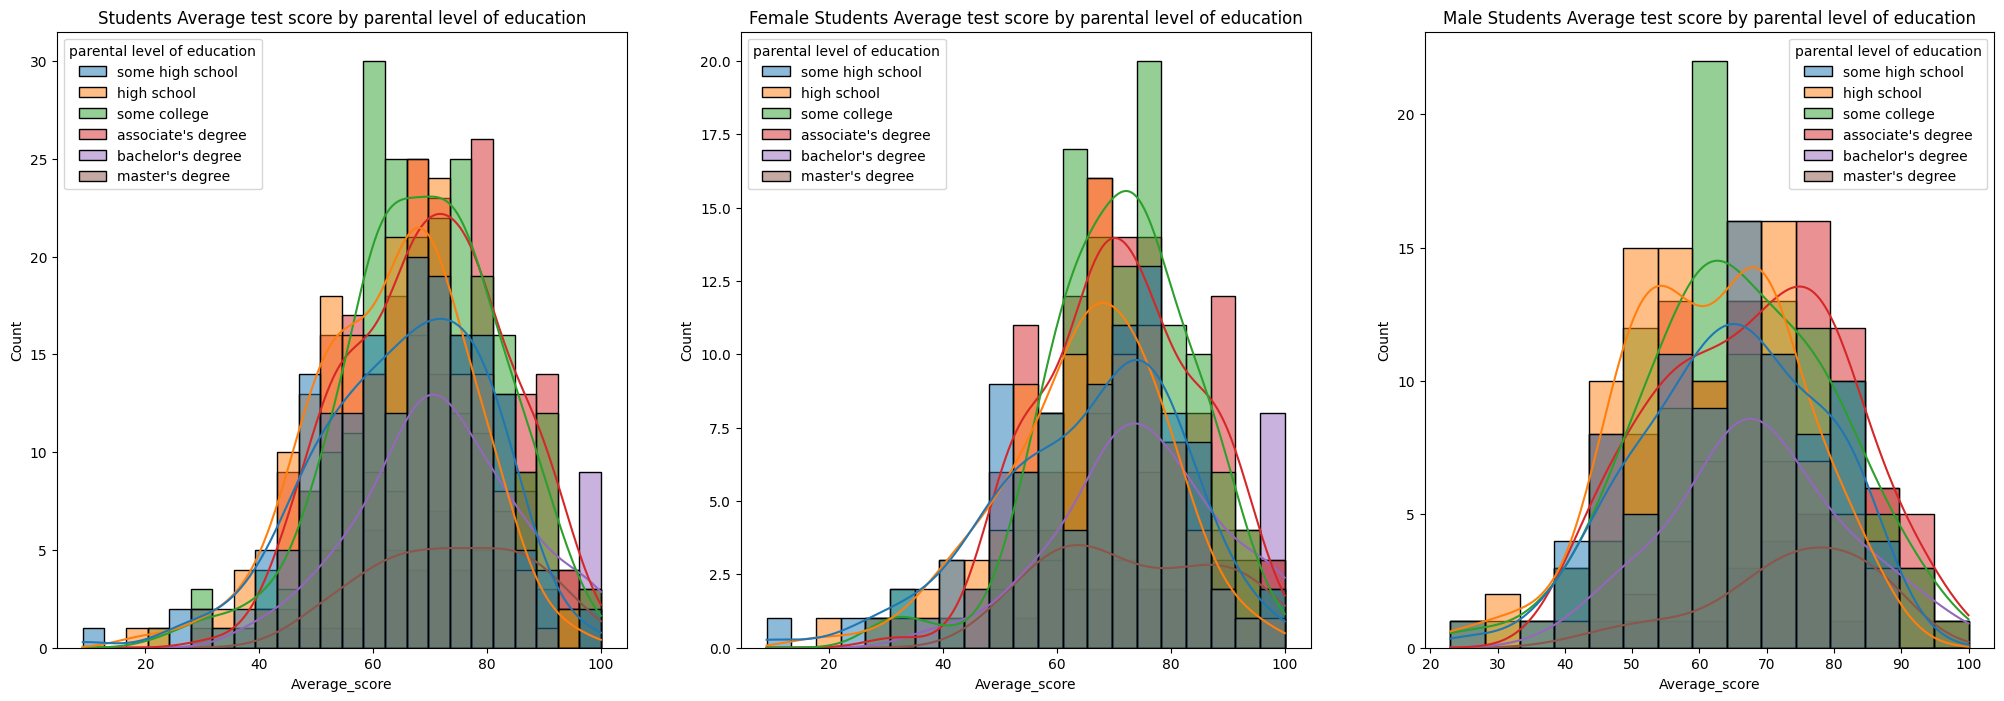

In [23]:
plt.subplots(1,3, figsize=(25,8))

plt.subplot(131)
plt.title("Students Average test score by parental level of education")
sns.histplot(data=df, x='Average_score', kde=True, hue='parental level of education',hue_order=['some high school', 'high school', 'some college',"associate's degree", "bachelor's degree", "master's degree"])

plt.subplot(132)
plt.title("Female Students Average test score by parental level of education")
sns.histplot(data=df[df.gender=='female'], x='Average_score', kde=True, hue='parental level of education',hue_order=['some high school', 'high school', 'some college',"associate's degree", "bachelor's degree", "master's degree"])

plt.subplot(133)
plt.title("Male Students Average test score by parental level of education")
sns.histplot(data=df[df.gender=='male'], x='Average_score', kde=True, hue='parental level of education', hue_order=['some high school', 'high school', 'some college',"associate's degree", "bachelor's degree", "master's degree"])

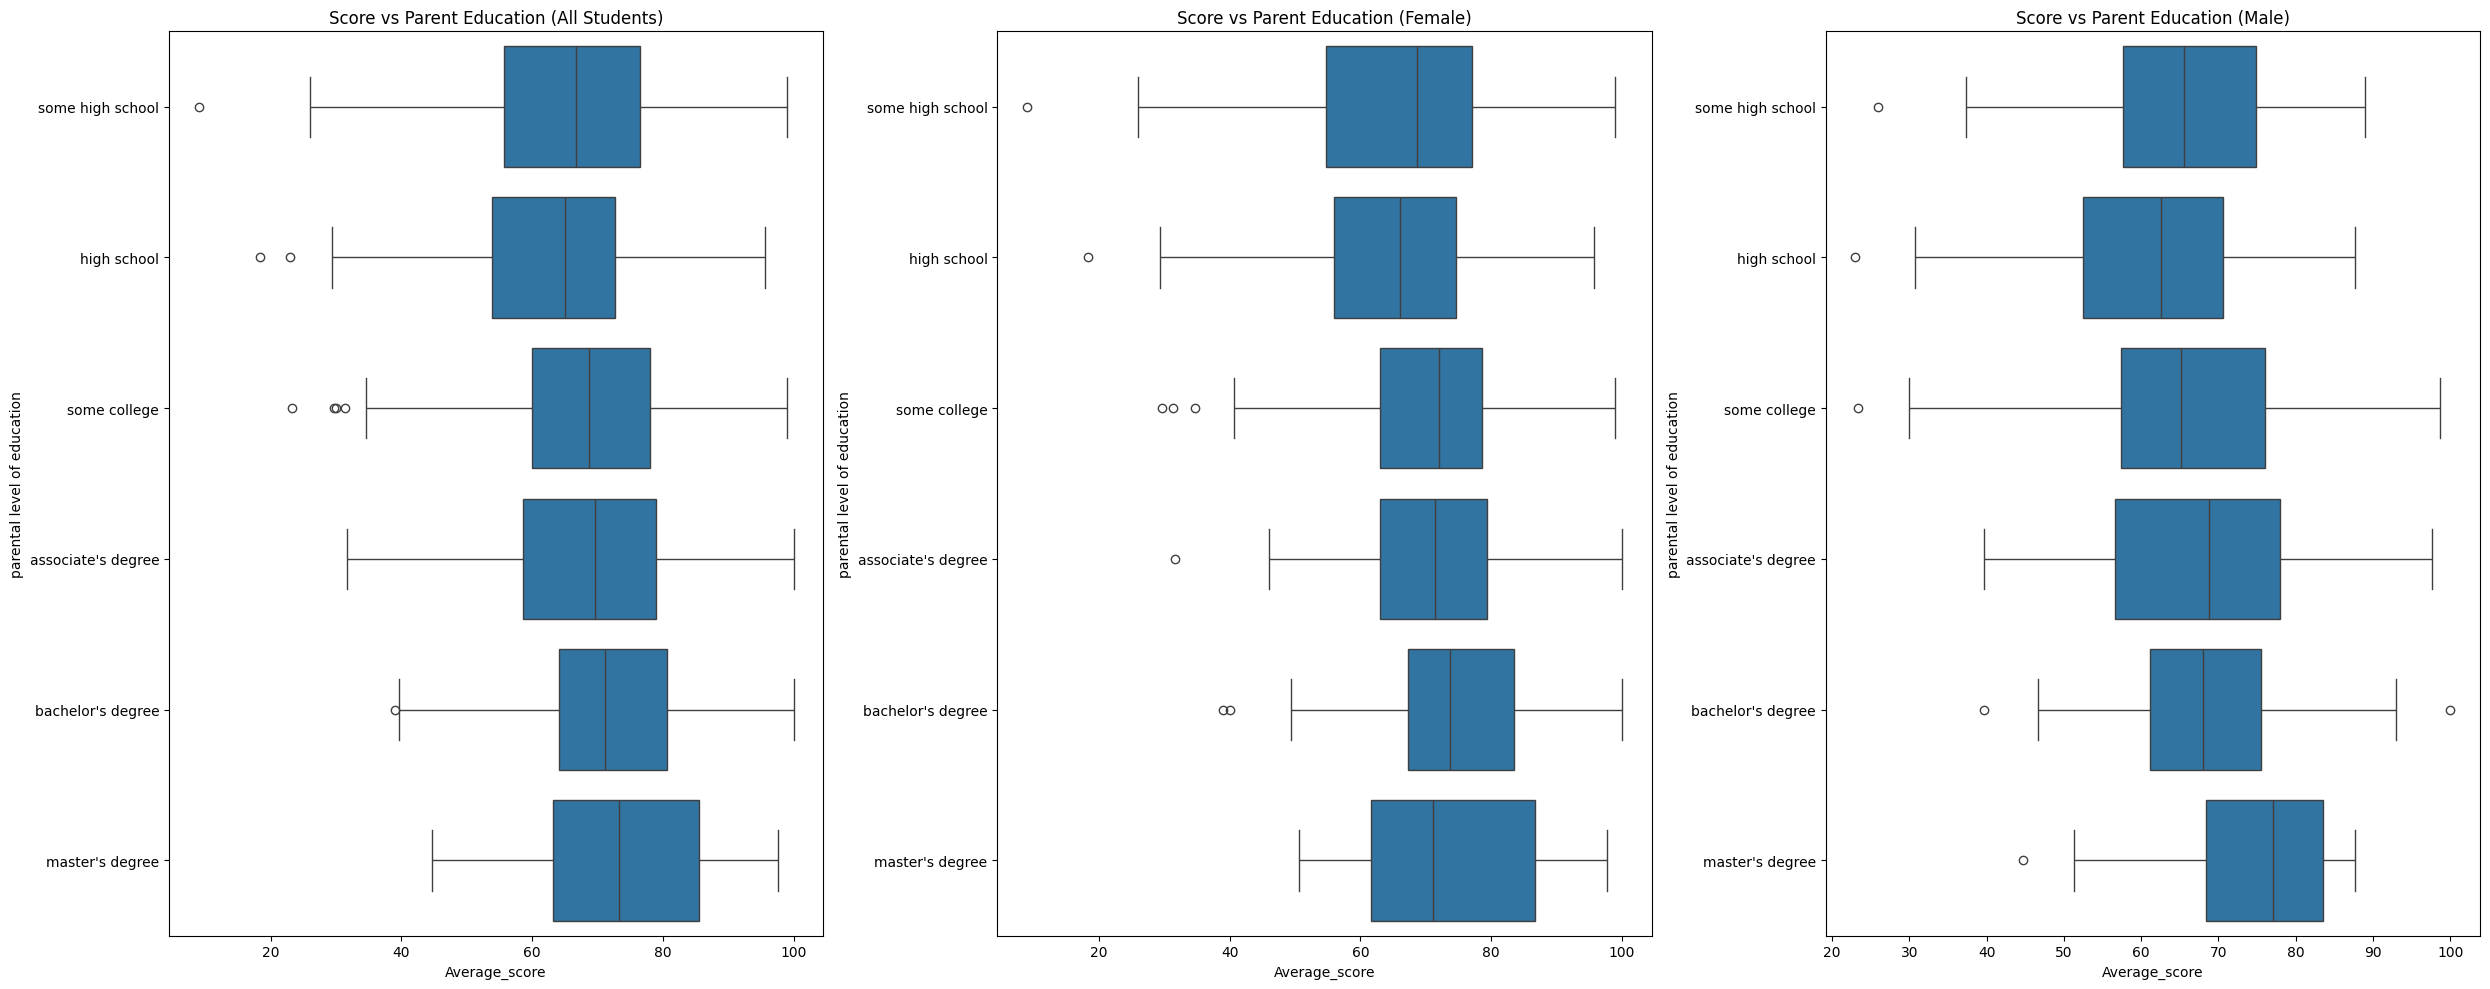

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the figure
plt.subplots(1, 3, figsize=(25, 10))

# 1. Total distribution by Parent Degree
plt.subplot(131)
plt.title("Score vs Parent Education (All Students)")
sns.boxplot(data=df, x='Average_score', y='parental level of education', order=['some high school', 'high school', 'some college',"associate's degree", "bachelor's degree", "master's degree"])

# 2. Female specific distribution
plt.subplot(132)
plt.title("Score vs Parent Education (Female)")
sns.boxplot(data=df[df.gender=='female'], x='Average_score', y='parental level of education', order=['some high school', 'high school', 'some college',"associate's degree", "bachelor's degree", "master's degree"])

# 3. Male specific distribution
plt.subplot(133)
plt.title("Score vs Parent Education (Male)")
sns.boxplot(data=df[df.gender=='male'], x='Average_score', y='parental level of education', order=['some high school', 'high school', 'some college',"associate's degree", "bachelor's degree", "master's degree"])

plt.tight_layout()
plt.show()


In [25]:
print(df.columns.tolist())


['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course', 'math score', 'reading score', 'writing score', 'Total_score', 'Average_score']


In [26]:
# Calculate mean scores grouped by parental education
impact = df.groupby('parental level of education')[['math score', 'reading score', 'writing score', 'Average_score']].mean()
impact.sort_values(by='Average_score', ascending=False)


,math score,reading score,writing score,Average_score
parental level of education,,,,
master's degree,69.745763,75.372881,75.677966,73.598870
bachelor's degree,69.389831,73.000000,73.381356,71.923729
associate's degree,67.882883,70.927928,69.896396,69.569069
some college,67.128319,69.460177,68.840708,68.476401
some high school,63.497207,66.938547,64.888268,65.108007
high school,62.137755,64.704082,62.448980,63.096939


In [27]:
from scipy.stats import f_oneway

# Create groups for each education level
groups = [df[df['parental level of education'] == level]['Average_score'] 
          for level in df['parental level of education'].unique()]

# Perform ANOVA
stat, p_value = f_oneway(*groups)

print(f"F-Statistic: {stat:.4f}, P-Value: {p_value:.4f}")

if p_value < 0.05:
    print("Result: Parental education level DOES significantly impact scores.")
else:
    print("Result: No statistically significant impact found.")


F-Statistic: 10.7531, P-Value: 0.0000
Result: Parental education level DOES significantly impact scores.


In [28]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(endog=df['Average_score'], 
                          groups=df['parental level of education'], 
                          alpha=0.05)
print(tukey)


tukey = pairwise_tukeyhsd(endog=df['Average_score'], 
                          groups=df['parental level of education'], 
                          alpha=0.05)
print(tukey)


            Multiple Comparison of Means - Tukey HSD, FWER=0.05             
      group1             group2      meandiff p-adj   lower    upper  reject
----------------------------------------------------------------------------
associate's degree bachelor's degree   2.3547 0.6743  -2.1739  6.8832  False
associate's degree       high school  -6.4721    0.0 -10.3682 -2.5761   True
associate's degree   master's degree   4.0298 0.3567  -1.7924   9.852  False
associate's degree      some college  -1.0927 0.9618  -4.8488  2.6635  False
associate's degree  some high school  -4.4611 0.0183  -8.4541  -0.468   True
 bachelor's degree       high school  -8.8268    0.0 -13.4584 -4.1952   True
 bachelor's degree   master's degree   1.6751 0.9748  -4.6629  8.0132  False
 bachelor's degree      some college  -3.4473 0.2479   -7.962  1.0673  False
 bachelor's degree  some high school  -6.8157 0.0006 -11.5293 -2.1022   True
       high school   master's degree  10.5019    0.0   4.5992 16.4047   True

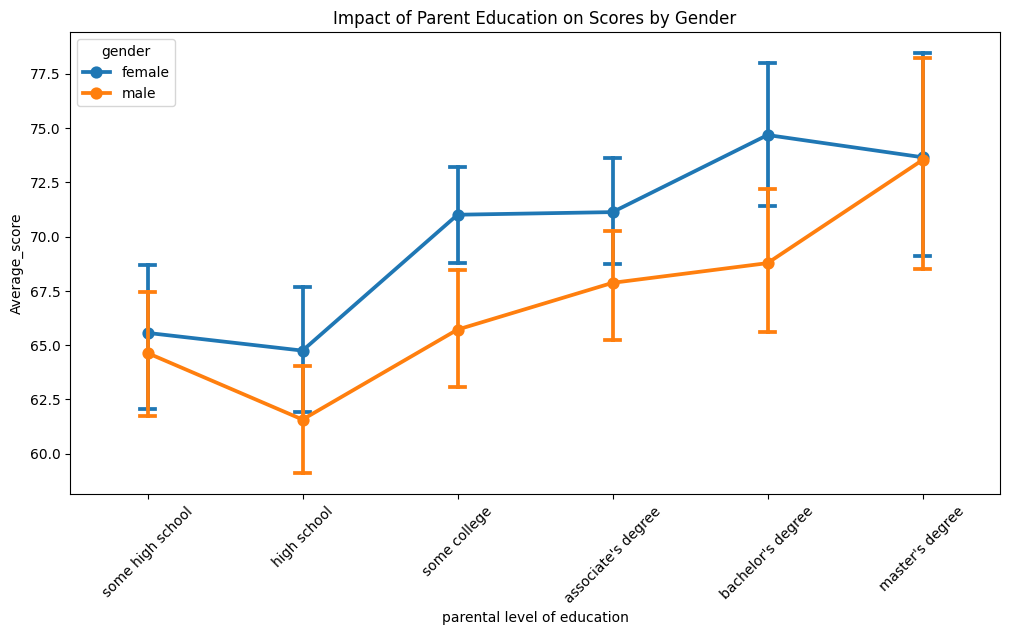

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.pointplot(data=df, x='parental level of education', y='Average_score', hue='gender', 
              capsize=.1, order=['some high school', 'high school', 'some college', 
                                "associate's degree", "bachelor's degree", "master's degree"])
plt.xticks(rotation=45)
plt.title('Impact of Parent Education on Scores by Gender')
plt.show()


In [30]:
pivot = df.pivot_table(values='Average_score', 
                       index='parental level of education', 
                       columns='gender', 
                       aggfunc='mean')
print(pivot.sort_values(by='female', ascending=False))


gender                          female       male
parental level of education                      
bachelor's degree            74.671958  68.775758
master's degree              73.648148  73.521739
associate's degree           71.123563  67.867925
some college                 71.002825  65.716049
some high school             65.564103  64.636364
high school                  64.748227  61.575163


We see improvements in scores when parents are more educated on average in general irrespective of degree
Males with parents having associates degree seems to have a higher performing average, while females score better with masters degree

#### Effect of race/ethnicity on test scores

/tmp/ipykernel_1270948/80912112.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='race/ethnicity', palette='viridis')


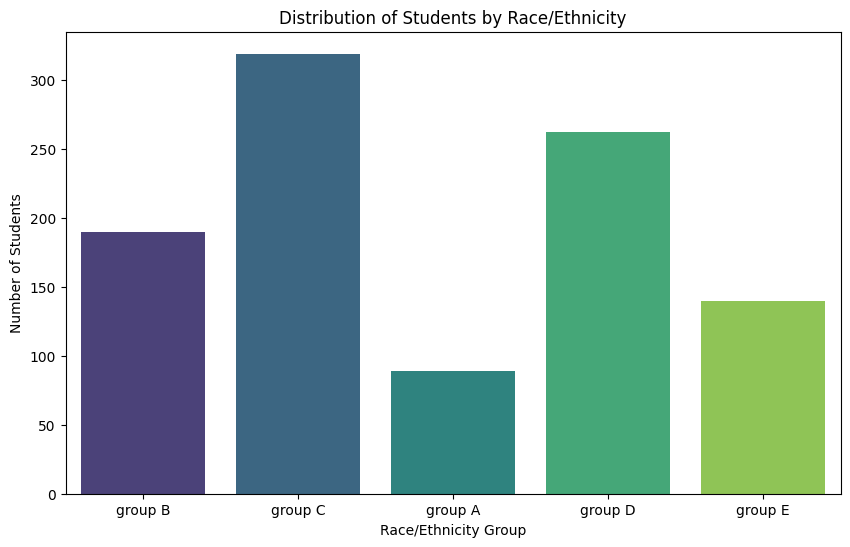

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
# Using countplot to automatically calculate frequencies
sns.countplot(data=df, x='race/ethnicity', palette='viridis')

plt.title('Distribution of Students by Race/Ethnicity')
plt.xlabel('Race/Ethnicity Group')
plt.ylabel('Number of Students')
plt.show()


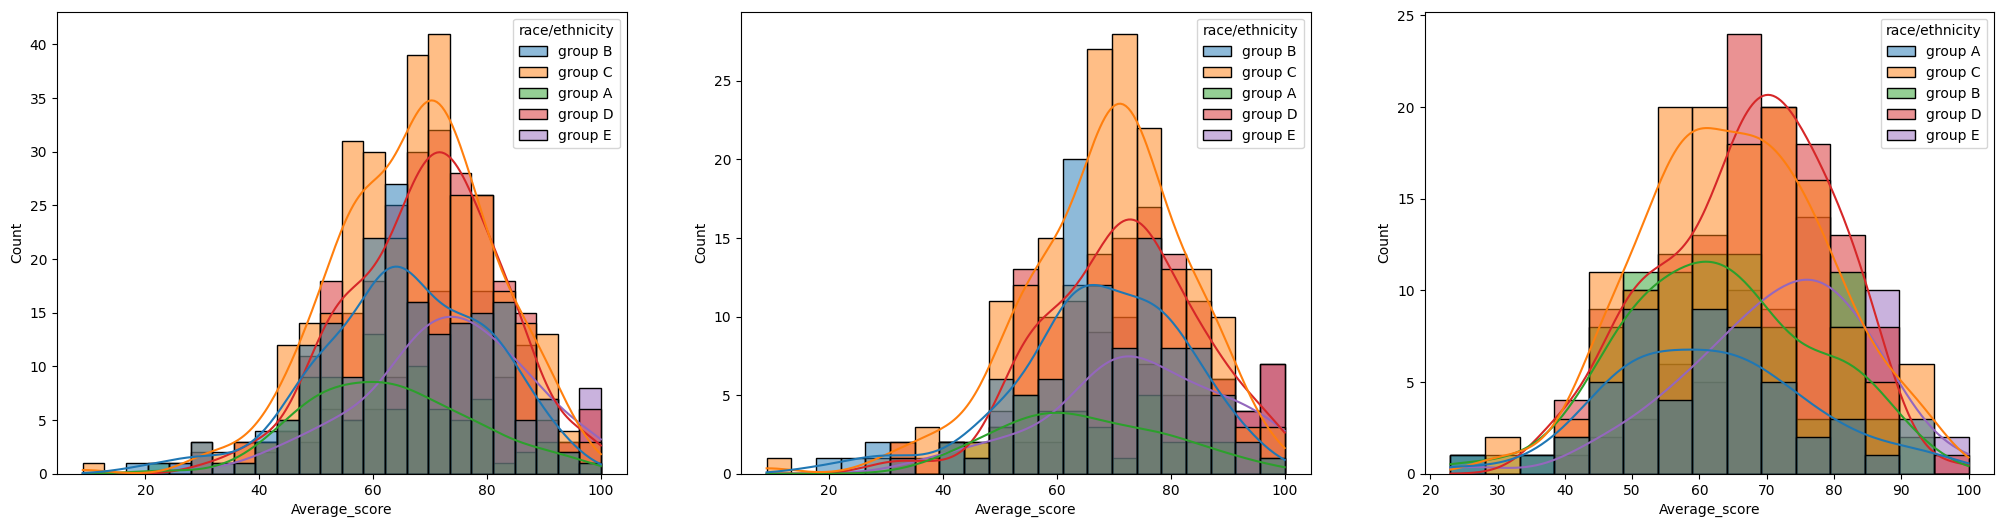

In [32]:
plt.subplots(1,3,figsize=(25,6))
plt.subplot(131)
ax =sns.histplot(data=df,x='Average_score',kde=True,hue='race/ethnicity')
plt.subplot(132)
ax =sns.histplot(data=df[df.gender=='female'],x='Average_score',kde=True,hue='race/ethnicity')
plt.subplot(133)
ax =sns.histplot(data=df[df.gender=='male'],x='Average_score',kde=True,hue='race/ethnicity')
plt.show()

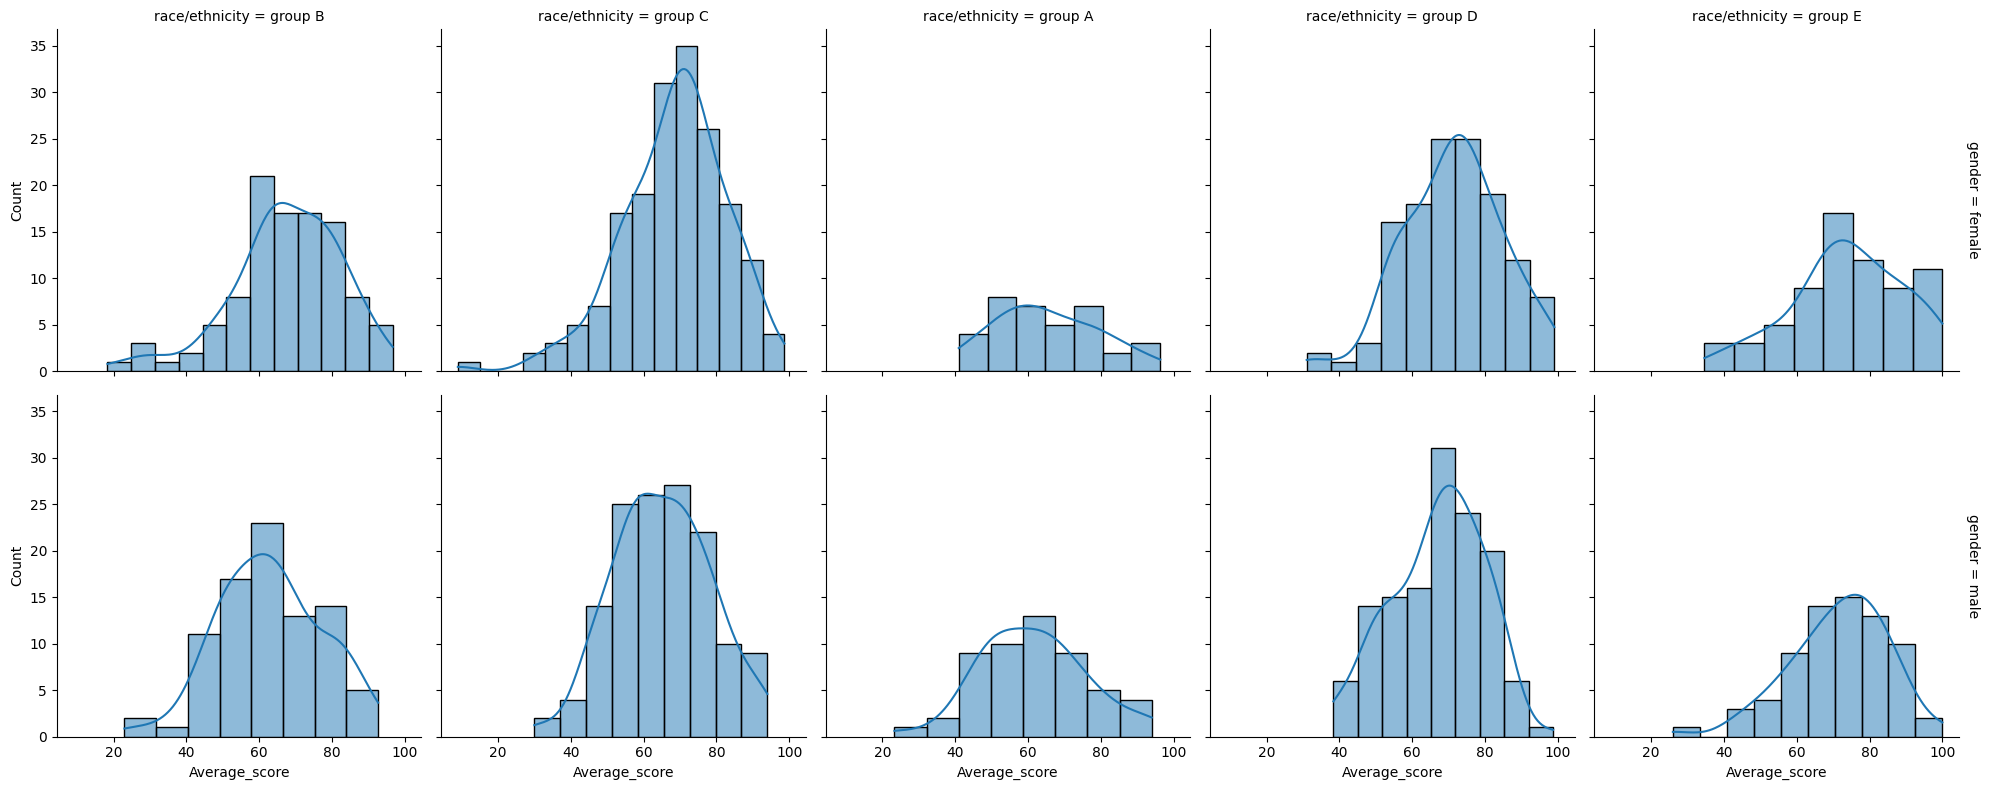

In [33]:
# Rows = Gender, Columns = Race/Ethnicity
g = sns.FacetGrid(df, col="race/ethnicity", row="gender", margin_titles=True, height=4)
g.map(sns.histplot, "Average_score", kde=True)
plt.show()


In [34]:
df.groupby(['race/ethnicity'])[['Average_score']].agg(['mean', 'min','max', 'std'])

Average_score                                  
                        mean        min         max        std
race/ethnicity                                                
group A            62.992509  23.333333   96.333333  14.444598
group B            65.468421  18.333333   96.666667  14.732133
group C            67.131661   9.000000   98.666667  13.872211
group D            69.179389  31.000000   99.000000  13.252776
group E            72.752381  26.000000  100.000000  14.565016

In [35]:
ethnic_groups=df['race/ethnicity'].unique().tolist()
for group in range(len(ethnic_groups)):

    print(ethnic_groups[group])
    desc=df[df['race/ethnicity']==ethnic_groups[group]].describe()['Average_score']
    print(desc)

group B
count    190.000000
mean      65.468421
std       14.732133
min       18.333333
25%       56.666667
50%       65.000000
75%       76.833333
max       96.666667
Name: Average_score, dtype: float64
group C
count    319.000000
mean      67.131661
std       13.872211
min        9.000000
25%       57.666667
50%       68.333333
75%       77.000000
max       98.666667
Name: Average_score, dtype: float64
group A
count    89.000000
mean     62.992509
std      14.444598
min      23.333333
25%      52.000000
50%      61.333333
75%      73.000000
max      96.333333
Name: Average_score, dtype: float64
group D
count    262.000000
mean      69.179389
std       13.252776
min       31.000000
25%       60.333333
50%       70.000000
75%       78.583333
max       99.000000
Name: Average_score, dtype: float64
group E
count    140.000000
mean      72.752381
std       14.565016
min       26.000000
25%       64.666667
50%       73.500000
75%       82.416667
max      100.000000
Name: Average_score, dty

#### Insight
- Group A performs significantly worse than other groups on average.
- Group E performs the best on average

#### 4.2) Maximum scores of students in all three subjects

In [36]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score', 'Total_score', 'Average_score'],
      dtype='str')

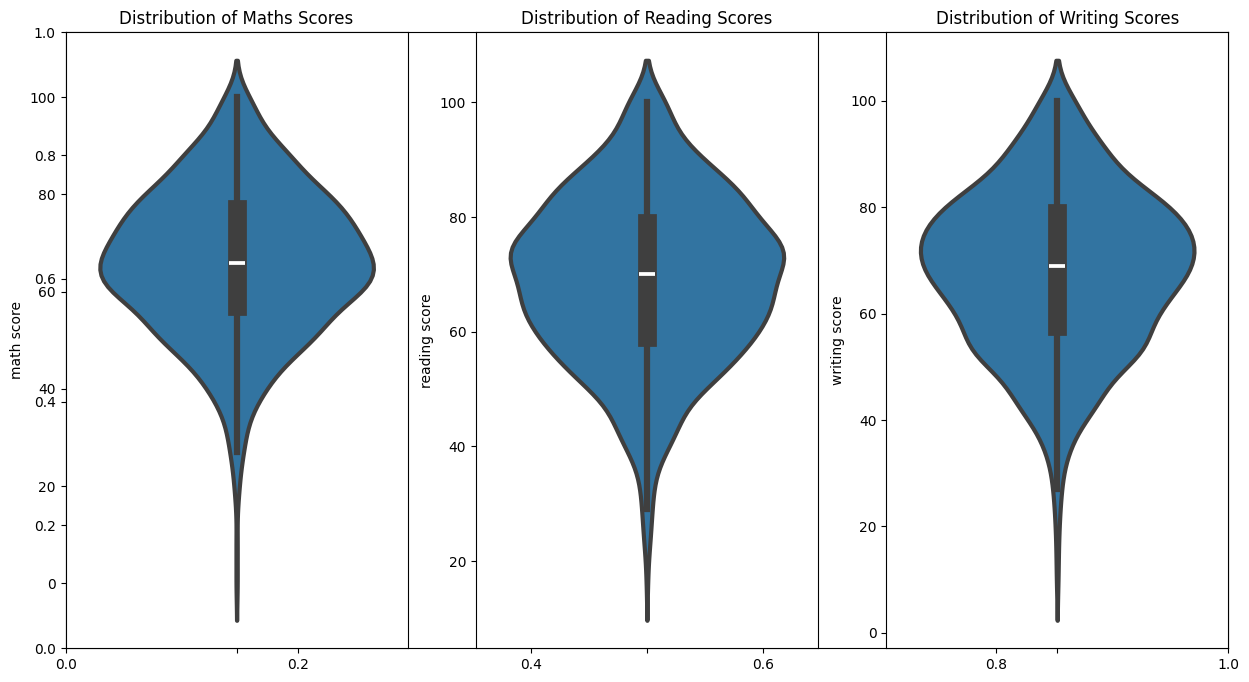

In [56]:
plt.subplots(figsize=(15,8))

plt.subplot(1,3,1)
plt.title("Distribution of Maths Scores")
sns.violinplot(data= df, y='math score', linewidth=3)

plt.subplot(1,3,2)
plt.title("Distribution of Reading Scores")
sns.violinplot(data= df, y='reading score', linewidth=3)

plt.subplot(1,3,3)
plt.title("Distribution of Writing Scores")
sns.violinplot(data= df, y='writing score', linewidth=3)

plt.show()

##### Insight
- Most student seem to score between 60 to 80 irrespective of the subject

#### 4.3) Understanding percentage feature distribution

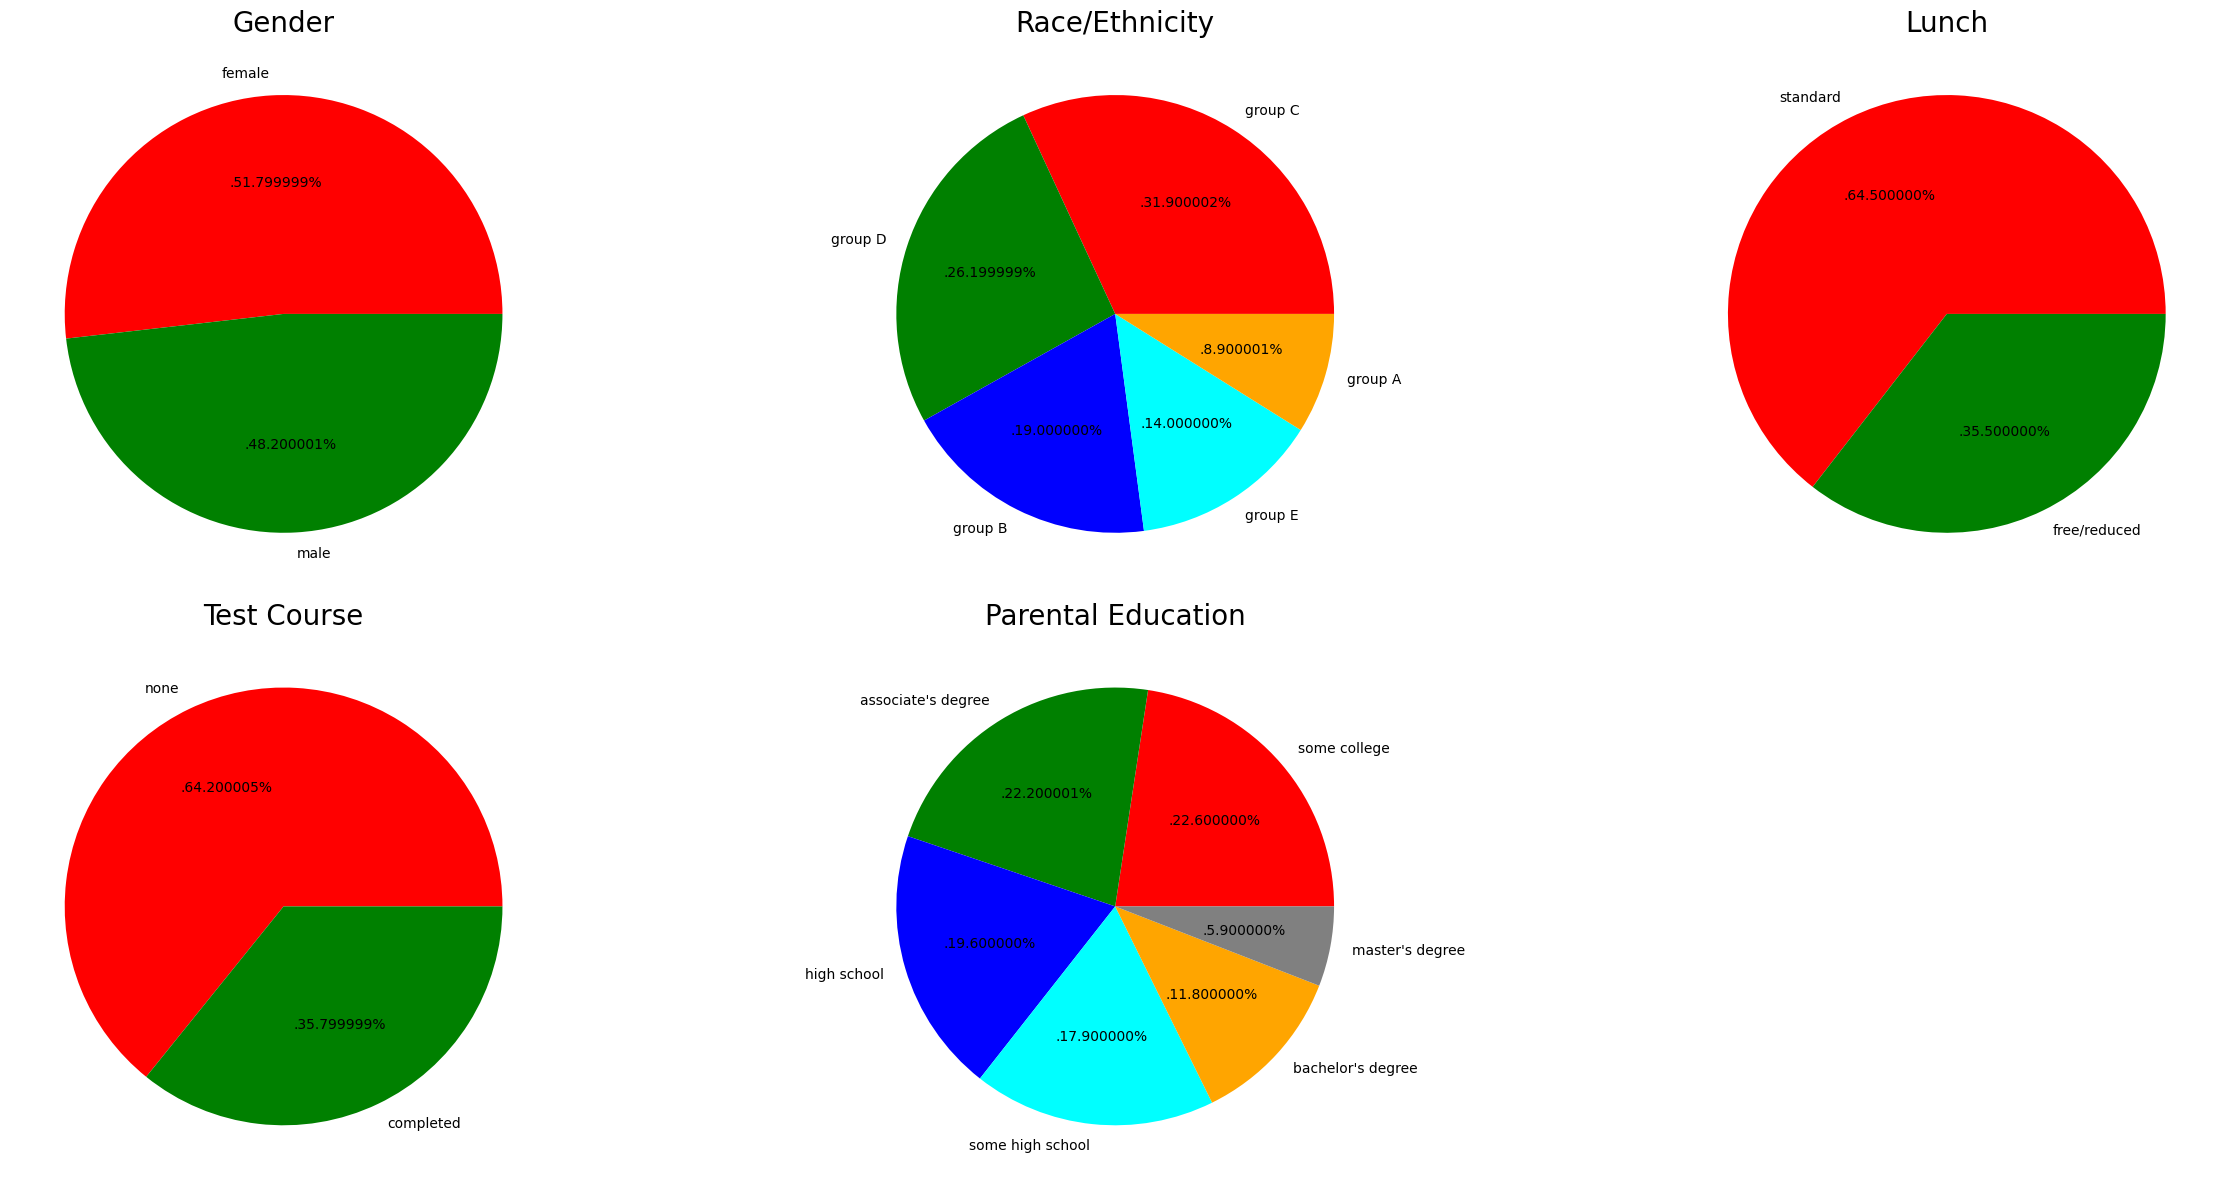

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd 

fig, ax = plt.subplots(2, 3, figsize=(25, 12)) 

# Flatten the axes array to easily iterate through them
ax_flat = ax.flatten()

# --- Plotting ---

# Plot 1: Gender
size = df['gender'].value_counts()
color = ['red','green']
ax_flat[0].pie(size, colors=color, labels=size.index, autopct='.%2f%%') 
ax_flat[0].set_title('Gender', fontsize=20)
ax_flat[0].axis('off')

# Plot 2: Race/Ethnicity
size = df['race/ethnicity'].value_counts()
color = ['red', 'green', 'blue', 'cyan','orange']
ax_flat[1].pie(size, colors=color, labels=size.index, autopct='.%2f%%')
ax_flat[1].set_title('Race/Ethnicity', fontsize=20)
ax_flat[1].axis('off')

# Plot 3: Lunch
size = df['lunch'].value_counts()
color = ['red','green']
ax_flat[2].pie(size, colors=color, labels=size.index, autopct='.%2f%%')
ax_flat[2].set_title('Lunch', fontsize=20)
ax_flat[2].axis('off')

# Plot 4: Test Course
size = df['test preparation course'].value_counts()
color = ['red','green']
ax_flat[3].pie(size, colors=color, labels=size.index, autopct='.%2f%%')
ax_flat[3].set_title('Test Course', fontsize=20)
ax_flat[3].axis('off')

# Plot 5: Parental Education
size = df['parental level of education'].value_counts()
color = ['red', 'green', 'blue', 'cyan','orange','grey'] 
ax_flat[4].pie(size, colors=color, labels=size.index, autopct='.%2f%%')
ax_flat[4].set_title('Parental Education', fontsize=20)
ax_flat[4].axis('off')

# --- Hide the 6th (empty) axis ---
fig.delaxes(ax[1, 2]) # Delete the axis at row 1 (index 1), column 2 (index 2)

plt.tight_layout()
plt.show()
